二叉树层序遍历结构：
  第0层: [10]
  第1层: [5, 15]
  第2层: [3, 7, None, 20]
  第3层: [None, None, None, None, None, None]


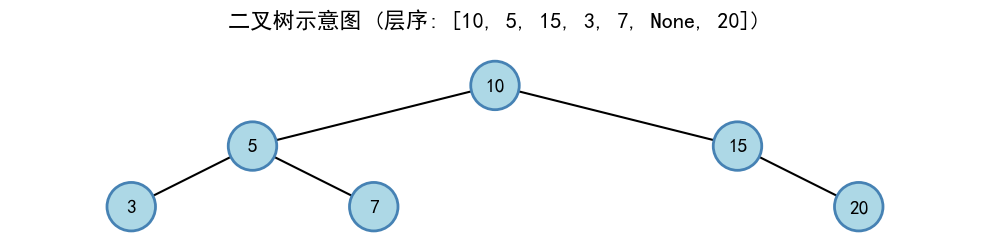

In [4]:
from collections import deque
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib import rcParams
rcParams['font.sans-serif'] = ['SimHei']       # 使用黑体显示中文
rcParams['axes.unicode_minus'] = False         # 正常显示负号

class TreeNode:
    def __init__(self, val=0, left=None, right=None):
        self.val = val
        self.left = left
        self.right = right

def build_tree_from_list(values):
    if not values or values[0] is None:
        return None

    root = TreeNode(values[0])
    queue = deque([root])
    i = 1

    while queue and i < len(values):
        node = queue.popleft()

        if i < len(values) and values[i] is not None:
            node.left = TreeNode(values[i])
            queue.append(node.left)
        i += 1

        if i < len(values) and values[i] is not None:
            node.right = TreeNode(values[i])
            queue.append(node.right)
        i += 1

    return root

def print_tree(root):
    if not root:
        print('空树')
        return

    queue = deque([(root, 0)])
    levels = {}

    while queue:
        node, depth = queue.popleft()
        if depth not in levels:
            levels[depth] = []
        levels[depth].append(node.val if node else None)

        if node:
            queue.append((node.left, depth + 1))
            queue.append((node.right, depth + 1))
        elif depth < max(levels.keys(), default=0):
            queue.append((None, depth + 1))
            queue.append((None, depth + 1))

    print('二叉树层序遍历结构：')
    for depth in sorted(levels.keys()):
        nodes = levels[depth]
        print(f'  第{depth}层: {nodes}')

def draw_tree(root):
    if not root:
        print('空树，无法绘制')
        return

    def get_height(node):
        if not node:
            return 0
        return 1 + max(get_height(node.left), get_height(node.right))

    height = get_height(root)
    positions = {}
    edges = []
    min_gap = 2.0

    def collect_positions(node, depth, pos):
        if not node:
            return
        x = pos
        y = -depth
        positions[node] = (x, y)

        if node.left:
            left_pos = pos - min_gap * (2 ** (height - depth - 1)) / 2
            edges.append(((x, y), (left_pos, -(depth + 1))))
            collect_positions(node.left, depth + 1, left_pos)

        if node.right:
            right_pos = pos + min_gap * (2 ** (height - depth - 1)) / 2
            edges.append(((x, y), (right_pos, -(depth + 1))))
            collect_positions(node.right, depth + 1, right_pos)

    collect_positions(root, 0, 0)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.set_aspect('equal')
    ax.axis('off')

    for (x1, y1), (x2, y2) in edges:
        ax.plot([x1, x2], [y1, y2], 'k-', linewidth=1.5)

    for node, (x, y) in positions.items():
        circle = patches.Circle((x, y), 0.4, facecolor='lightblue',
                                edgecolor='steelblue', linewidth=2, zorder=3)
        ax.add_patch(circle)
        ax.text(x, y, str(node.val), ha='center', va='center',
                fontsize=14, fontweight='bold', zorder=4)

    ax.set_xlim(-min_gap * 2 ** (height - 1), min_gap * 2 ** (height - 1))
    ax.set_ylim(-height + 0.5, 0.5)

    plt.title('二叉树示意图 (层序: [10, 5, 15, 3, 7, None, 20])', fontsize=16, pad=20)
    plt.tight_layout()
    plt.show()

values = [10, 5, 15, 3, 7, None, 20]
root = build_tree_from_list(values)

print('=' * 50)
print_tree(root)
print('=' * 50)

draw_tree(root)

         10
        /  \
       5    15
      / \     \
     3   7    20